In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
seed = 42
prefix_path = "../"

In [3]:
data = pd.read_csv(prefix_path + "data/salary_dataset.csv", index_col=0)

In [4]:
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [5]:
X, y = np.array(data["YearsExperience"]), np.array(data["Salary"])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=seed)

In [7]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((24,), (6,), (24,), (6,))

In [72]:
MAX_ITERATIONS = 2e5
TOLERANCE = 1e-2

In [39]:
def normalization(data: np.array) -> np.array:
    min_value, max_value = np.min(data), np.max(data)
    diff = max_value - min_value
    return (data - min_value) / diff if diff != 0 else data

def standardization(data: np.array) -> np.array:
    mean_data = np.mean(data)
    std_data = np.std(data)
    return (data - mean_data) / std_data if std_data != 0 else data

In [21]:
def f(X: np.array, w: float, b: float) -> float:
    return w * X + b

In [22]:
def loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
    # Mean Squared Error (MSE)
    if metric.strip().lower() == "mse":
        return (1/(2 * X.shape[0])) * np.sum( (f(X, w, b) - y)**2 )

In [23]:
def update_coefficients(X: np.array, y: np.array, w: float, b: float, lr: float, metric: str, method: str) -> float:
    # Gradient Descent (GD)
    if method.strip().lower() == "gd":
        def d_loss_function(X: np.array, y: np.array, w: float, b: float, metric: str) -> float:
            # Derivatives of Mean Squared Error
            if metric.strip().lower() == "mse":
                dw = (1/X.shape[0]) * np.sum( (f(X, w, b) - y) * X )
                db = (1/X.shape[0]) * np.sum( f(X, w, b) - y )
                return dw, db
    
        dw, db = d_loss_function(X, y, w, b, metric)
        aux_w = w - lr * dw
        aux_b = b - lr * db
        return aux_w, aux_b

In [24]:
def gradient_descent(X: np.array, y: np.array, lr: float, metric: str):
    # Defining returnning structure
    hist_cost = list()
    hist_w_b = list()

    i = 1 # Iterations counter
    # Generating initial values for w and b
    w, b = 6, 7
    # Initial cost
    cost = loss_function(X, y, w, b, metric)
    hist_cost.append(cost)
    while (cost > TOLERANCE) and i < MAX_ITERATIONS:
        w, b = update_coefficients(X, y, w, b, lr, metric, method="gd")    # Update the coefficients of f
        cost = loss_function(X, y, w, b, metric)             # The total cost related to new coefficients
        # Saving the history
        hist_w_b.append((w, b))
        hist_cost.append(cost)
        i += 1
    
    return hist_w_b, hist_cost, i

In [25]:
def linear_regression(X: np.array, y: np.array, lr: float, metric: str, method: str) -> float:
    if method.strip().lower() == "gd":
        return gradient_descent(X, y, lr, metric)

In [40]:
X_train_norm = normalization(X_train)
y_train_norm = normalization(y_train)

X_train_z = standardization(X_train)
y_train_z = standardization(y_train)

In [86]:
inputs = {"X": X_train_norm, "y": y_train_norm, "lr": 0.1, "metric": "mse", "method": "gd"}
list_w_b, list_cost, total_iterations = linear_regression(**inputs)

In [87]:
len(list_cost), total_iterations

(152, 152)

In [88]:
def learning_curve(cost: list) -> None:
    x_len = len(cost)
    plt.plot(np.arange(x_len), cost, label="Loss")
    plt.xticks(ticks=np.arange(0, x_len+1, (MAX_ITERATIONS / 1e1)), rotation=45)
    plt.legend()

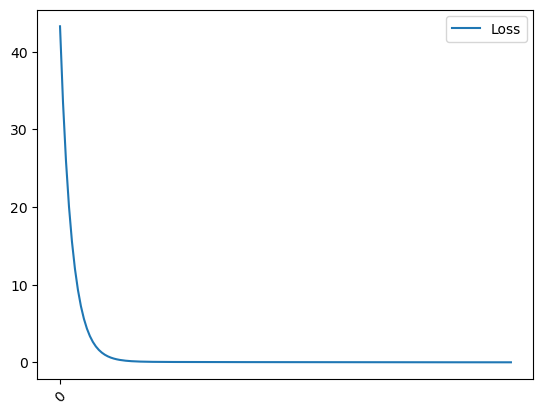

In [89]:
learning_curve(list_cost)

In [78]:
list_cost

[np.float64(37.10733967852333),
 np.float64(37.099922127468),
 np.float64(37.09250605984869),
 np.float64(37.085091475368756),
 np.float64(37.07767837373156),
 np.float64(37.070266754640556),
 np.float64(37.062856617799255),
 np.float64(37.055447962911224),
 np.float64(37.0480407896801),
 np.float64(37.040635097809535),
 np.float64(37.033230887003285),
 np.float64(37.02582815696516),
 np.float64(37.01842690739902),
 np.float64(37.01102713800878),
 np.float64(37.00362884849841),
 np.float64(36.99623203857196),
 np.float64(36.98883670793354),
 np.float64(36.98144285628727),
 np.float64(36.974050483337415),
 np.float64(36.966659588788225),
 np.float64(36.95927017234402),
 np.float64(36.95188223370922),
 np.float64(36.94449577258827),
 np.float64(36.93711078868568),
 np.float64(36.92972728170602),
 np.float64(36.92234525135392),
 np.float64(36.914964697334064),
 np.float64(36.90758561935121),
 np.float64(36.90020801711016),
 np.float64(36.89283189031578),
 np.float64(36.885457238673),
 np.

In [79]:
min(list_cost)

np.float64(0.017729921329092794)